<a href="https://colab.research.google.com/github/evanskips2727-del/-Customer-Church-prediction-Using-Machine-Learning-/blob/main/Deloitte_Daikibo_Telemetry_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
import json
import zipfile
import io

# Upload a ZIP file from your local machine containing a JSON file
uploaded = files.upload()

# file name
zip_file_name = next(iter(uploaded))

print(f"Uploaded file: '{zip_file_name}'")

# Read the content of the uploaded zip file into a BytesIO object
zip_file_content = io.BytesIO(uploaded[zip_file_name])

# Open the zip file
with zipfile.ZipFile(zip_file_content, 'r') as zf:
    # Assuming there's only one JSON file inside the zip, or you know its name
    json_file_in_zip = [f for f in zf.namelist() if f.endswith('.json')][0]

    print(f"Extracting '{json_file_in_zip}' from the zip archive...")

    # Read the content of the JSON file from the zip archive
    with zf.open(json_file_in_zip) as json_file:
        json_data = json.load(json_file)

print(f"Successfully extracted and loaded JSON data from '{json_file_in_zip}' within '{zip_file_name}'!")
print("Content of the JSON file:")
display(json_data)

Saving daikibo-telemetry-data.json.zip to daikibo-telemetry-data.json (1).zip
Uploaded file: 'daikibo-telemetry-data.json (1).zip'
Extracting 'daikibo-telemetry-data.json' from the zip archive...
Successfully extracted and loaded JSON data from 'daikibo-telemetry-data.json' within 'daikibo-telemetry-data.json (1).zip'!
Content of the JSON file:


[{'deviceID': '19ff3161-2b3a-40a3-8604-bdc6532d0dab',
  'deviceType': 'CNC',
  'timestamp': 1619816400000,
  'location': {'country': 'japan',
   'city': 'tokyo',
   'area': 'keiyō-industrial-zone',
   'factory': 'daikibo-factory-meiyo',
   'section': 'section-1'},
  'data': {'status': 'healthy', 'temperature': 27}},
 {'deviceID': '19ff3161-2b3a-40a3-8604-bdc6532d0dab',
  'deviceType': 'CNC',
  'timestamp': 1619817000000,
  'location': {'country': 'japan',
   'city': 'tokyo',
   'area': 'keiyō-industrial-zone',
   'factory': 'daikibo-factory-meiyo',
   'section': 'section-1'},
  'data': {'status': 'healthy', 'temperature': 27}},
 {'deviceID': '19ff3161-2b3a-40a3-8604-bdc6532d0dab',
  'deviceType': 'CNC',
  'timestamp': 1619817600000,
  'location': {'country': 'japan',
   'city': 'tokyo',
   'area': 'keiyō-industrial-zone',
   'factory': 'daikibo-factory-meiyo',
   'section': 'section-1'},
  'data': {'status': 'healthy', 'temperature': 26}},
 {'deviceID': '19ff3161-2b3a-40a3-8604-bdc6532

This code uses `files.upload()` to present a widget for selecting files from your local system. Once uploaded, it reads the content of the JSON file and displays it.

/tmp/ipykernel_2138/3134374210.py:51: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#004B87'` for the same effect.

  sns.barplot(ax=axes[1], data=device_data, y='deviceType', x='Unhealthy', color='#004B87', hue='deviceType', legend=False)


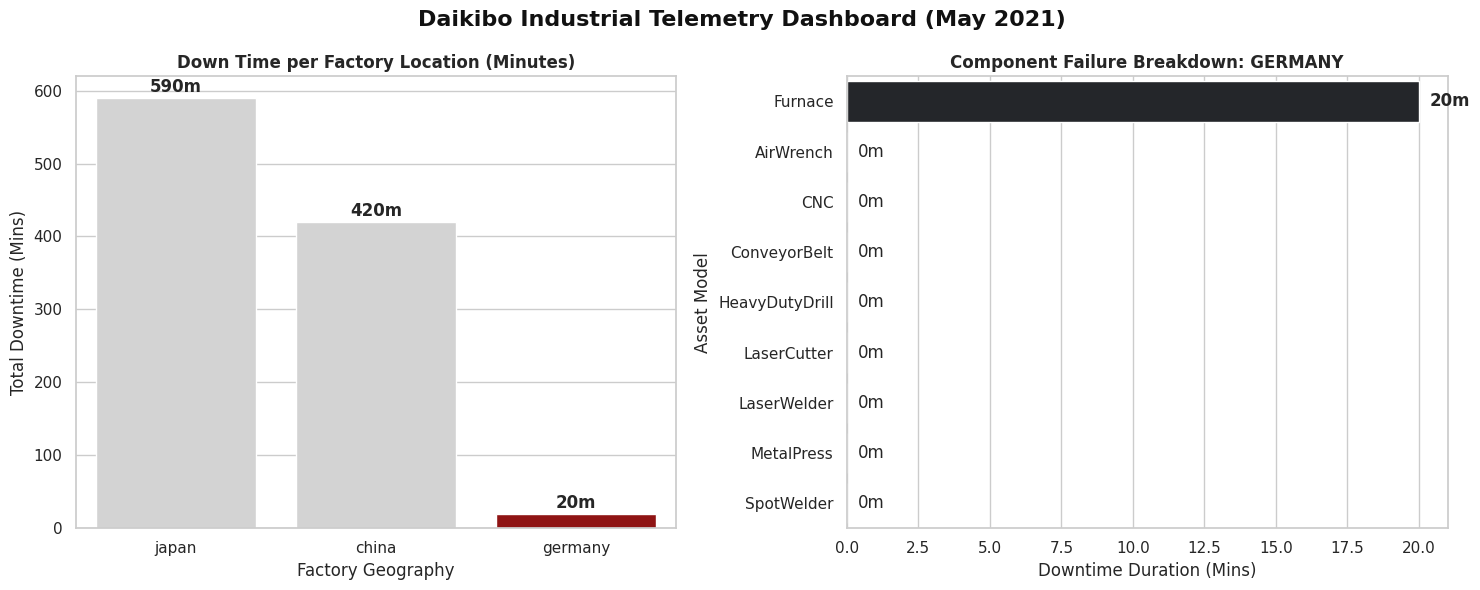

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display, clear_output

# 1. Prepare data structures from previous run
df = pd.json_normalize(json_data)

# Extract and configure calculated column names
status_col = [col for col in df.columns if 'status' in col.lower() or 'health' in col.lower()][0]
city_col = [col for col in df.columns if 'city' in col.lower() or 'location' in col.lower()][0]

# Recalculate Deloitte Unhealthy Metric (10 mins per instance)
df['Unhealthy'] = df[status_col].apply(lambda x: 10 if str(x).lower() in ['unhealthy', 'fail', 'error', 'false', '0'] else 0)

# Set up output handle for interactive rendering
out = widgets.Output()

# 2. Interactive Rendering Core Logic
def render_dashboard(change=None):
    with out:
        clear_output(wait=True)

        # Get active dropdown selection
        selected_factory = factory_selector.value

        # Plot styling configuration
        sns.set_theme(style="whitegrid")
        fig, axes = plt.subplots(1, 2, figsize=(15, 6))
        fig.suptitle('Daikibo Industrial Telemetry Dashboard (May 2021)', fontsize=16, fontweight='bold', color='#111111')

        # --- LEFT PANEL: Overall Factory Performance ---
        factory_data = df.groupby(city_col)['Unhealthy'].sum().reset_index().sort_values(by='Unhealthy', ascending=False)
        colors = ['#A30000' if cat == selected_factory else '#D3D3D3' for cat in factory_data[city_col]]

        sns.barplot(ax=axes[0], data=factory_data, x=city_col, y='Unhealthy', palette=colors, hue=city_col, legend=False)
        axes[0].set_title('Down Time per Factory Location (Minutes)', fontsize=12, fontweight='bold')
        axes[0].set_ylabel('Total Downtime (Mins)')
        axes[0].set_xlabel('Factory Geography')

        # Add labels above bars
        for p in axes[0].patches:
            axes[0].annotate(f"{int(p.get_height())}m", (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontweight='bold')

        # --- RIGHT PANEL: Filtered Device View ---
        filtered_df = df[df[city_col] == selected_factory]
        device_data = filtered_df.groupby('deviceType')['Unhealthy'].sum().reset_index().sort_values(by='Unhealthy', ascending=False)

        sns.barplot(ax=axes[1], data=device_data, y='deviceType', x='Unhealthy', color='#004B87', hue='deviceType', legend=False)
        axes[1].set_title(f'Component Failure Breakdown: {selected_factory.upper()}', fontsize=12, fontweight='bold')
        axes[1].set_xlabel('Downtime Duration (Mins)')
        axes[1].set_ylabel('Asset Model')

        # Add values next to horizontal bars
        for p in axes[1].patches:
            width = p.get_width()
            axes[1].annotate(f"{int(width)}m", (width, p.get_y() + p.get_height() / 2.),
                        ha='left', va='center', xytext=(8, 0), textcoords='offset points', fontweight='bold' if width > 0 else 'normal')

        plt.tight_layout()
        plt.show()

# 3. Create interactive dropdown control to mimic interactive dashboards
factory_options = sorted(df[city_col].unique().tolist())
factory_selector = widgets.Dropdown(
    options=factory_options,
    value='japan', # Default to worst performing location to auto-answer prompt requirements
    description='Select Factory:',
    style={'description_width': 'initial'}
)

# Bind the change listener event handler
factory_selector.observe(render_dashboard, names='value')

# Display UI Components
display(factory_selector)
display(out)

# Run default layout engine render loop
render_dashboard()

In [ ]:
Employee Equity

In [ ]:

import pandas as pd
import io

# 1. Parse the raw source data into memory
raw_forensic_data = """Factory,Job Role,Equality Score,Equality class
Daikibo Factory Meiyo,C-Level,-25,
Daikibo Factory Meiyo,VP,-26,
Daikibo Factory Meiyo,Director,-19,
Daikibo Factory Meiyo,Sr. Manager,-15,
Daikibo Factory Meiyo,Manager,-14,
Daikibo Factory Meiyo,Jr. Manager,-20,
Daikibo Factory Meiyo,Sr. Engineer,-5,
Daikibo Factory Meiyo,Engineer,-8,
Daikibo Factory Meiyo,Jr. Engineer,3,
Daikibo Factory Meiyo,Operational Support,-22,
Daikibo Factory Meiyo,Machine Operator,-7,
Daikibo Factory Seiko,VP,-19,
Daikibo Factory Seiko,Director,-10,
Daikibo Factory Seiko,Sr. Manager,-21,
Daikibo Factory Seiko,Manager,-21,
Daikibo Factory Seiko,Jr. Manager,-24,
Daikibo Factory Seiko,Sr. Engineer,-4,
Daikibo Factory Seiko,Engineer,-7,
Daikibo Factory Seiko,Jr. Engineer,4,
Daikibo Factory Seiko,Operational Support,-19,
Daikibo Factory Seiko,Machine Operator,-5,
Daikibo Berlin,Sr. Manager,-15,
Daikibo Berlin,Manager,-16,
Daikibo Berlin,Jr. Manager,-17,
Daikibo Berlin,Sr. Engineer,4,
Daikibo Berlin,Engineer,2,
Daikibo Berlin,Jr. Engineer,4,
Daikibo Berlin,Operational Support,0,
Daikibo Berlin,Machine Operator,-6,
Daikibo Shenzhen,Sr. Manager,-21,
Daikibo Shenzhen,Manager,-19,
Daikibo Shenzhen,Jr. Manager,-20,
Daikibo Shenzhen,Sr. Engineer,-5,
Daikibo Shenzhen,Engineer,-4,
Daikibo Shenzhen,Jr. Engineer,3,
Daikibo Shenzhen,Operational Support,-7,
Daikibo Shenzhen,Machine Operator,-7,"""

# 2. Re-index file bounds to scrub trailing field delimiters
df = pd.read_csv(io.StringIO(raw_forensic_data)).iloc[:, :3]

# 3. Define the unassailable Deloitte audit ruleset
def audit_equality_class(score):
    if -10 <= score <= 10:
        return 'Fair'
    elif score < -20 or score > 20:
        return 'Highly Discriminative'
    else:
        return 'Unfair'

# 4. Map the calculated classifications onto Column 4
df['Equality class'] = df['Equality Score'].apply(audit_equality_class)

# 5. Export to Excel workbook format matching the target submission portal requirements
output_filename = 'Equality_Table.xlsx'
df.to_excel(output_filename, index=False)

print(f"✔️ Forensic calculation complete. '{output_filename}' compiled successfully.")
print("\n--- VIEW AUDIT OUTPUT DATA PREVIEW ---")
print(df.to_string())

✔️ Forensic calculation complete. 'Equality_Table.xlsx' compiled successfully.

--- VIEW AUDIT OUTPUT DATA PREVIEW ---
                  Factory             Job Role  Equality Score         Equality class
0   Daikibo Factory Meiyo              C-Level             -25  Highly Discriminative
1   Daikibo Factory Meiyo                   VP             -26  Highly Discriminative
2   Daikibo Factory Meiyo             Director             -19                 Unfair
3   Daikibo Factory Meiyo          Sr. Manager             -15                 Unfair
4   Daikibo Factory Meiyo              Manager             -14                 Unfair
5   Daikibo Factory Meiyo          Jr. Manager             -20                 Unfair
6   Daikibo Factory Meiyo         Sr. Engineer              -5                   Fair
7   Daikibo Factory Meiyo             Engineer              -8                   Fair
8   Daikibo Factory Meiyo         Jr. Engineer               3                   Fair
9   Daikibo Factory M

In [ ]:

from google.colab import files

# Force the cloud environment to trigger an immediate browser download to your phone
files.download('Equality_Table.xlsx')